# Lab 2: Linear regression
---

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

Load the data set in the companion **demodataset.csv**

In [2]:
data = np.loadtxt("demodataset.csv", delimiter=",")

np.set_printoptions(precision=5)
np.set_printoptions(suppress=True)
data

array([[     1.2,  39344. ],
       [     1.4,  46206. ],
       [     1.6,  37732. ],
       [     2.1,  43526. ],
       [     2.3,  39892. ],
       [     3. ,  56643. ],
       [     3.1,  60151. ],
       [     3.3,  54446. ],
       [     3.3,  64446. ],
       [     3.8,  57190. ],
       [     4. ,  63219. ],
       [     4.1,  55795. ],
       [     4.1,  56958. ],
       [     4.2,  57082. ],
       [     4.6,  61112. ],
       [     5. ,  67939. ],
       [     5.2,  66030. ],
       [     5.4,  83089. ],
       [     6. ,  81364. ],
       [     6.1,  93941. ],
       [     6.9,  91739. ],
       [     7.2,  98274. ],
       [     8. , 101303. ],
       [     8.3, 113813. ],
       [     8.8, 109432. ],
       [     9.1, 105583. ],
       [     9.6, 116970. ],
       [     9.7, 112636. ],
       [    10.4, 122392. ],
       [    10.6, 121873. ]])

---
Extract the first column in the data set to vector **x** and the second column to vector **y**.   

Plot a figure showing the dataset as: { $(x^{(i)},(x^{(i)}) | i=1,…, m $}

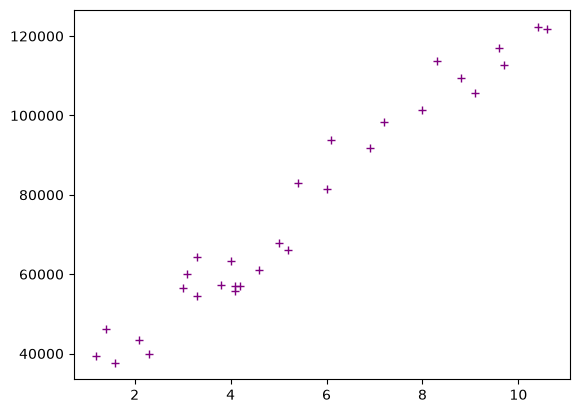

In [3]:
x=data[:,0] # x is the first  column in the data set
y=data[:,1] # y is the second column in the data set

#plot the data points 
plt.plot(x, y, "+", color = "purple")
plt.show()

---
1. a) Compute $θ_0^*$ and $θ_1^*$ for the line of best fit. \
\
i) using scipy.stats.linregress(): https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

Check the documentation above first.

The function takes as parameters:

- **`x`** - independent variable
- **`y`** - dependent variable

And returns:

- **`slope`** - slope of the regression line.
- **`intercept`** - intercept of the regression line.
- **`rvalue`** - Pearson correlation coefficient. The square of `rvalue` is equal to the coefficient of determination ($R^2$).
- **`pvalue`** - p-value for a hypothesis test whose null hypothesis is that the slope is zero.
- **`stderr`** - standard error of the estimated slope (gradient), under the assumption of residual normality.


**Store the returned values in the following variables, in this exact order:**

```python
Θ1, Θ0, r, p, std_err = 9449.962321455076, 24848.2039665232, 0.9782416184887599, 1.143068109227156e-20, 378.7545742388215

In [4]:
# call the function HERE: (1 line of code)
result = scipy.stats.linregress(x, y)
print(result)


LinregressResult(slope=np.float64(9449.962321455076), intercept=np.float64(24848.2039665232), rvalue=np.float64(0.9782416184887598), pvalue=np.float64(1.1430681092272361e-20), stderr=np.float64(378.7545742388224), intercept_stderr=np.float64(2306.653709065012))


In [5]:
print('Θ0 (intercept) = {:.3f}'.format(result.intercept)) # to print theta0 (the intercept y axis)
print('Θ1 (slope)     = {:.3f}'.format(result.slope)) # to print theta1 (the slope)

Θ0 (intercept) = 24848.204
Θ1 (slope)     = 9449.962


1 a) \
\
ii)	implementing the linear regression model below using **NumPy** functions:

$$
\begin{split}
\theta_0 &= \bar y - \theta_1 \bar x\\
\\
\theta_1 &= \frac {SS_{xy}}{SS_{xx}}=
\frac
{ \sum_{i=1}^{m} \left[\left(x_i - \bar {x}\right) \left(y_i - \bar {y}\right) \right]}
{ \sum_{i=1}^{m} \left( x_i - \bar x \right)^2 }
\end{split}
$$


In [6]:

def linearRegression(x, y):
    meanX = np.mean(x)
    meanY = np.mean(y)
    m = len(x)   
    xs = np.subtract(x, meanX)
    ys = np.subtract(y, meanY)
    num = np.dot(xs, ys)
    den = np.dot(xs, xs)
    theta1 = num / den 
    theta0 = meanY - theta1 * meanX
    return theta0, theta1


intercept, slope = linearRegression(x, y)

1 a)\
\
iii)	check that i) and ii) produce the same results

In [7]:
print("1º Abordagem")
print('Θ0 (intercept) = {:.3f}'.format(result.intercept))
print('Θ1 (slope) = {:.3f}'.format(result.slope))
print("------------------")
print("2º Abordagem")
print('intercept = {:.3f}'.format(intercept))
print('slope = {:.3f}'.format(slope))

1º Abordagem
Θ0 (intercept) = 24848.204
Θ1 (slope) = 9449.962
------------------
2º Abordagem
intercept = 24848.204
slope = 9449.962


---
1. b) Print the dataset and superimpose the line of best fit to the data

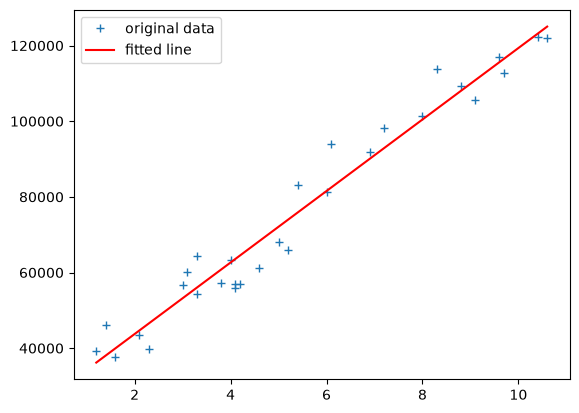

In [8]:
plt.plot(x, y, '+', label='original data')
plt.plot(x, intercept + slope*x, 'r', label='fitted line')
plt.legend()
plt.show()

---
1. c)	Predict y for x = 4.6. What is the corresponding residual? Superimpose on the graphic obtained in b)

*A residuals is the difference between the observed ($y$) and predicted response ($h$).*


Prediction of x = 4.6: y = 68318.02919999999
Actual value of x = 4.6: y = 61112.0
Residual: 7206.02919999999


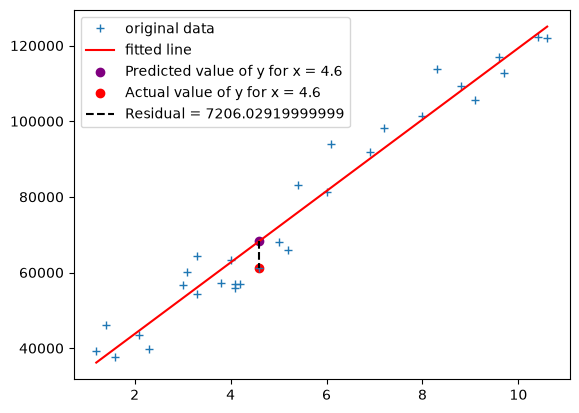

In [9]:
def predict_v1(x):
    return 9449.962*x+24848.204

prediction = predict_v1(4.6)
print(f"Prediction of x = 4.6: y = {prediction}")
index = 0

for i in range(0, len(data[:,0])):
    if data[i,0] == 4.6:
        index = i
        break
        
actual_value = data[index, 1]
print(f"Actual value of x = 4.6: y = {actual_value}")

residual = abs(actual_value - prediction)
print(f"Residual: {residual}")

plt.plot(x, y, '+', label='original data')
plt.plot(x, intercept + slope*x, 'r', label='fitted line')
plt.scatter(4.6, prediction, color='purple', label='Predicted value of y for x = 4.6')
plt.scatter(4.6, actual_value, color='red', label='Actual value of y for x = 4.6')
plt.plot([4.6, 4.6], [prediction, actual_value], linestyle='--', color='black', label=f'Residual = {residual}')
plt.legend()
plt.show()

d) Interpret the parameters of line of best fit (q0, q1) in the context of the dataset. What does the
slope tell you about the relationship between years of experience and salary? What does the
intercept represent?

The slope means at what rate does your salary grow over more years of experience.
The intercept is the average base salary of that profession.

e) Use your final linear regression model to predict the salary for a person with 20 years of
experience. Is this prediction an interpolation or an extrapolation? Briefly explain.

In [10]:
prediction2 = predict_v1(20)
print(f"Salary prediction for 20 years of experience : {prediction2}")

Salary prediction for 20 years of experience : 213847.444


---
2. a) \
\
i) Express the cost function in vector notation: $\qquad J(θ_0, \dots , θ_n) = \frac{1}{2m}\sum_{i=1}^{m} (h_θ(\mathbf x^{(i)}) - y^{(i)})^2$




- Considering a dataset with $m$ data points (or samples), $n$ features and 1 target or label.  
$\mathbf{X}$ matrix has $m$ rows, one for each data point, and $1+n$ columns, the leftmost for $bias$ and the rest for the features.  
$\mathbf{y}$ vector has $m$ rows, one for each target:

$$
\begin{split}
\mathbf{X}_{m\times(1+n)} &=
\begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} & \dots & x_n^{(1)}\\
1 & x_1^{(2)} & x_2^{(2)} & \dots & x_n^{(2)}\\
\vdots & \vdots & \vdots & & \vdots\\
1 & x_1^{(m)} & x_2^{(m)} & \dots & x_n^{(m)}
\end{bmatrix}
\qquad\qquad
\mathbf{y} =
\begin{bmatrix}
y^{(1)}\\
y^{(2)}\\
\vdots\\
y^{(m)}
\end{bmatrix}
\end{split}
$$

$\qquad$ and vector $\boldsymbol{\theta}$ for $1+n$ coefficients:

$$
\boldsymbol{\theta} =
\begin{bmatrix}
\theta_0\\
\theta_1\\
\vdots\\
\theta_n
\end{bmatrix}
$$

- The hypothesis function, for each $h_\theta^{(i)}$, where

$$
\mathbf{x}^{(i)} =
\begin{bmatrix}
1 & x_1^{(i)} & \dots & x_n^{(i)}
\end{bmatrix},
$$

given by:

$$
h_\theta(\mathbf{x}^{(i)})
=
\theta_0
+
\theta_1x_1^{(i)}
+
\theta_2x_2^{(i)}
+
\dots
+
\theta_nx_n^{(i)}
$$

- can be rewritten in vector form as the dot product of:

$$
\begin{split}
h_\theta(\mathbf{x}^{(i)})
&=
\begin{bmatrix}
1 & x_1^{(i)} & \dots & x_n^{(i)}
\end{bmatrix}
\begin{bmatrix}
\theta_0\\
\theta_1\\
\vdots\\
\theta_n
\end{bmatrix}\\
h_\theta(\mathbf{x}^{(i)})
&=
\mathbf{x}^{(i)}\boldsymbol{\theta}
\end{split}
$$


- and for $m$ data points, as:
$$
\begin{split}
h_\theta(\mathbf{X}) &= \mathbf{X}\boldsymbol{\theta}
\end{split}
$$

- this will compute vector $\mathbf{h}$ with $m$ elements:
  
$$
\mathbf{h} = \mathbf{X}\boldsymbol{\theta}
$$

- Now, expressing the cost (or loss) function: 

$$
J(\theta_0, \dots, \theta_n)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(
h_\theta(\mathbf{x}^{(i)}) - y^{(i)}
\right)^2
$$

- in vector notation:

$$ { J({\theta}) = \frac{1}{2m} \left(\;X{\theta}-\mathbf y\;\right)^T \left(\;X{\theta}-\mathbf y\;\right) } $$



---
2. a)\
\
ii) Compute $J(θ_0^*, θ_1^*)$ for the given dataset

In [11]:
# Variaveis usadas nos exercicios 2 e 3 (a partir do resultado do exercicio 1)
def predict(theta0, theta1, x):
    return theta0 + theta1 * x

theta0, theta1 = intercept, slope
X = np.column_stack((np.ones(len(x)), x))   # matriz m x 2 com a coluna de bias
Y = y.reshape(-1, 1)                         # vetor coluna m x 1
theta = np.array([[theta0], [theta1]])

In [12]:
def costFunction(X, Y, theta):
    prediction = np.dot(X, theta)
    error = prediction - Y

    J = np.dot(error.T, error) / (2 * len(Y))

    return J.item()
    
J = costFunction(X, Y, theta)

print('J = {:.3f}'.format(J))    

J = 15635475.861


---
2. a)\
\
iii) Show that point (average of X, average of Y) belongs to the line of best fit.

In [13]:
meanX = np.mean(x)
meanY = np.mean(y)

predictedMean = predict(theta0, theta1, meanX)

print('meanX = {:.4f}'.format(meanX))
print('meanY = {:.4f}'.format(meanY))
print('prediction = {:.4f}'.format(predictedMean))


meanX = 5.4133
meanY = 76004.0000
prediction = 76004.0000


---
2. b) For $θ_0^*$ and $θ_1^*$, plot the residuals *vs* the independent variable x. Print the mean and variance of the residuals. Briefly comment on what you observe.

*Residuals are the difference between the observed ($y$) and predicted responses ($h$).*

*If the model is appropriate for the data, this should be reflected in the residuals. In particular, the graph of **residuals vs. independent variable** should be centered around zero without any tendency:*

In [14]:
y_pred = predict(theta0, theta1, x)

res = y - y_pred

print('Mean = {:.3f}'.format(np.mean(res)))
print('Variance = {:.3f}'.format(np.var(res)))
print('Std = {:.3f}'.format(np.std(res)))


Mean = -0.000
Variance = 31270951.722
Std = 5592.044


The closer the residuals are from zero the smaller the cost J.

For the normal error regression model, it is assumed that the error term is normally distributed with null mean and
constant variance. The mean and variance of the residuals are: 

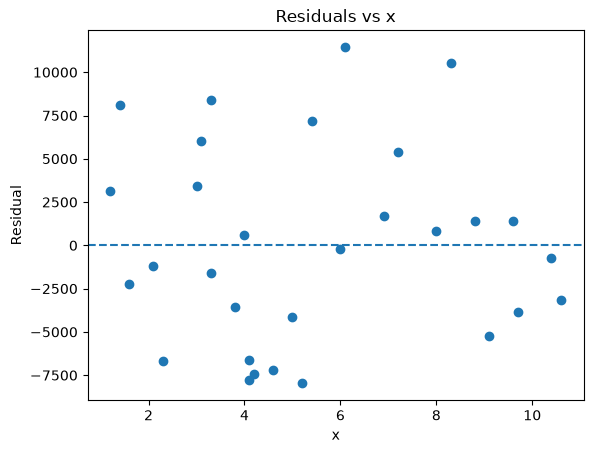

In [15]:
plt.plot(x, res, "o")
plt.axhline(0, linestyle="--")

plt.xlabel("x")
plt.ylabel("Residual")
plt.title("Residuals vs x")

plt.show()

---
2. c) For $θ_0^*$ and $θ_1^*$, analytically prove that the sum of residuals is zero. 


- ie. show that: $\qquad\qquad\qquad\qquad \sum_{i=1}^{m} \left( h_θ(x^{(i)}) - y^{(i)} \right) = 0 \qquad\qquad\qquad for: \qquad θ_0^*$,&emsp;$θ_1^*$

- since:

  $\qquad\qquad h_θ(x) = θ_0^* + θ_1^*x$

$$
\begin{split}
    \sum_{i=1}^{m} \left( h_θ(x^{(i)}) - y^{(i)}  \right) = \sum_{i=1}^{m} \left[ (θ_0^* + θ_1^*x)-y^{(i)} \right]
\end{split}
$$

- $θ_0^*$ is constant, so:
$$
\begin{split}
    &= mθ_0^*+ \sum_{i=1}^{m}(θ_1^*x^{(i)}-y^{(i)}) \\
    &= mθ_0^* + θ_1^* \sum_{i=1}^{m} x^{(i)} - \sum_{i=1}^{m} y^{(i)} 
\end{split}
$$

$\color{red}{\text{To complete ...}}$


In [16]:
res = predict(theta0, theta1, x) - y

print('Sum = {:.3e}'.format(np.sum(res)))

Sum = 2.910e-10


---
2. d) Prove that the derivative of the cost function in order to $\theta_j$ is:

$$
\begin{split}
& \frac{\partial}{\partial \theta_j} J(θ_0, \dots, θ_n) = 
 \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x_j^{(i)})-y^{(i)})   x_j^{(i)}\quad\text,\quad j=0,1 \dots n
\end{split}
$$

The derivative of the cost function in order to $\theta_j$:

$$
\begin{split}
& \frac{\partial}{\partial \theta_j} \quad J(\theta_0, \dots, \theta_n) \\
& \frac{\partial}{\partial \theta_j} \quad \frac{1}{2m}\sum_{i=1}^{m} (h_\theta(x_j^{(i)}) - y^{(i)})^2
\end{split}
$$

$$
\color{red}{\text{To complete ...}}
$$

List of derivative rules:

https://www.mathsisfun.com/calculus/derivatives-rules.html


---
3. a) Express in vector notation the following gradient descent updating expressions: </p>
$$\theta_j = \theta_j - \alpha \frac{1}{m} 
\sum_{i=1}^{m} (h_\theta(x_j^{(i)})-y^{(i)})   x_j^{(i)}\quad\text,\quad j=0,1 \dots n$$

using $\mathbf{h}$, $\mathbf{y}$, $\boldsymbol{\theta}$ and $\mathbf{X}$ as defined in 2. a) i):

$\color{red}{\text{To complete ...}}$

---
3. b) Apply gradient descent and linear regression to the dataset. Find $\theta_0*, \theta_1*$ and $J(\theta_0^*,\theta_1^*)$.

In [17]:
def gradientDescent(X, Y, alpha, maxIter, tol=1e-6):
    m = len(Y)

    theta = np.zeros((X.shape[1], 1))

    costs = [costFunction(X, Y, theta)]

    for i in range(maxIter):

        prediction = np.dot(X, theta)

        error = prediction - Y

        gradient = np.dot(X.T, error) / m

        theta = theta - alpha * gradient

        costs.append(costFunction(X, Y, theta))

        if np.linalg.norm(gradient) < tol:
            break

    return theta, np.array(costs)

alpha = 0.05

thetaGD, costsGD = gradientDescent(
    X,
    Y,
    alpha,
    maxIter=20000
)

print('Gradient Descent')
print('θ0 = {:.3f}'.format(thetaGD[0, 0]))
print('θ1 = {:.3f}'.format(thetaGD[1, 0]))
print('J = {:.3f}'.format(costsGD[-1]))
print('Iterations = {}'.format(len(costsGD) - 1))

print()

print('Linear Regression')
print('θ0 = {:.3f}'.format(theta0))
print('θ1 = {:.3f}'.format(theta1))
print('J = {:.3f}'.format(J))



Gradient Descent
θ0 = 24848.204
θ1 = 9449.962
J = 15635475.861
Iterations = 2159

Linear Regression
θ0 = 24848.204
θ1 = 9449.962
J = 15635475.861


---
3. c) What is the number of iterations and the value of the learning rate $\alpha$, that approximate the $\theta$ vector and the cost J obtained in 3. b) to those found in 1. a) and 2. a)?

In [18]:
print('Learning rate alpha =', alpha)
print('Number of iterations =', len(costsGD) - 1)

print('θ0 = {:.3f}'.format(thetaGD[0, 0]))
print('θ1 = {:.3f}'.format(thetaGD[1, 0]))
print('J = {:.3f}'.format(costsGD[-1]))




Learning rate alpha = 0.05
Number of iterations = 2159
θ0 = 24848.204
θ1 = 9449.962
J = 15635475.861
